In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

filepath = '/mnt/diffuse-shared/xray/steve/mdx-examples/lys_tri_model/export/lys_tri_goodvibes.h5'

with h5py.File(filepath, 'r') as f:
    I_data = f['maps/supercell/I'][()]   # full path as a string, works because it's a Dataset
    print(I_data.shape, I_data.dtype)

(319, 583, 585) float32


In [2]:
np.isnan(I_data).all()

np.False_

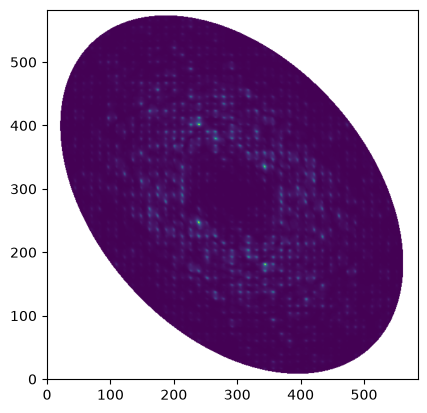

In [3]:
plt.imshow(I_data[7],origin='lower')

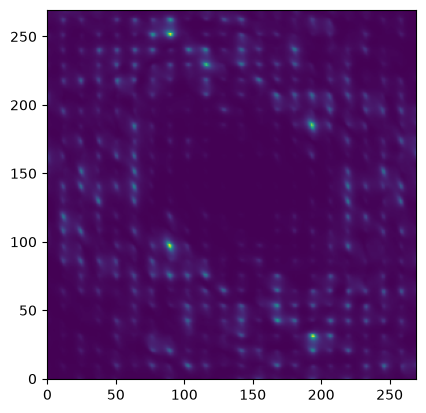

In [4]:
plt.imshow(I_data[7][150:420,150:420],origin='lower')

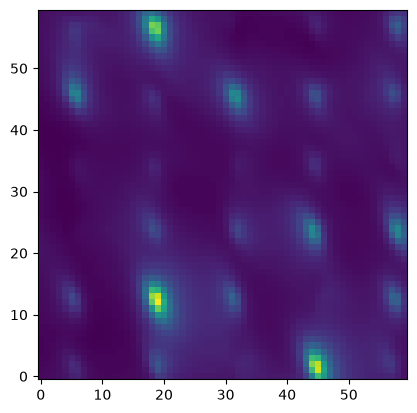

In [5]:
plt.imshow(I_data[7][300:360,130:190],origin='lower')

In [6]:
# #may have to pip install
# import imageio.v2 as imageio
# import io

# frames = []

# with h5py.File(filepath, 'r') as f:
#     I_data = f['maps/supercell/I']  # dataset object, not loaded into memory yet

#     # figure out a consistent color scale across all frames (optional but recommended)
#     vmin, vmax = None, None
#     # Uncomment to compute global min/max across the slice range for consistent scaling:
#     # sample = I_data[6:295, 300:360, 130:190]
#     # vmin, vmax = np.nanmin(sample), np.nanmax(sample)

#     for k in range(6, 295):  # 6 to 294 inclusive
#         fig, ax = plt.subplots(figsize=(5, 5))
#         im = ax.imshow(I_data[k][300:360, 130:190], origin='lower', vmin=vmin, vmax=vmax)
#         ax.set_title(f'h = {k}')
#         ax.axis('off')

#         # render figure to an in-memory buffer, then to an array
#         buf = io.BytesIO()
#         fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
#         plt.close(fig)
#         buf.seek(0)
#         frames.append(imageio.imread(buf))

# # write out the gif
# imageio.mimsave('lys_tri_goodvibes.gif', frames, fps=10)
# print("Saved GIF with", len(frames), "frames")

In [7]:
#may have to pip install this
import hdf5storage
data = hdf5storage.loadmat('/mnt/diffuse-shared/xray/steve/mdx-examples/lys_tri_model/proc/goodvibes_fit.mat')

Text(0.5, 0, 'Spring index')

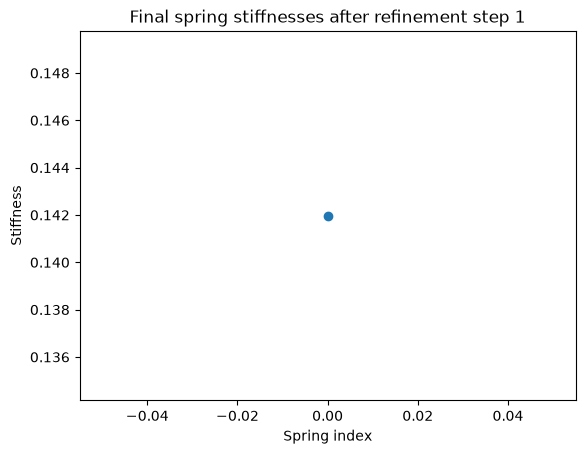

In [8]:
plt.scatter(np.arange(len(data['refineLog'][0][0][3].T[0])),data['refineLog'][0][0][3].T[0])
plt.title('Final spring stiffnesses after refinement step 1')
plt.ylabel('Stiffness')
plt.xlabel('Spring index')

Text(0.5, 0, 'Spring index')

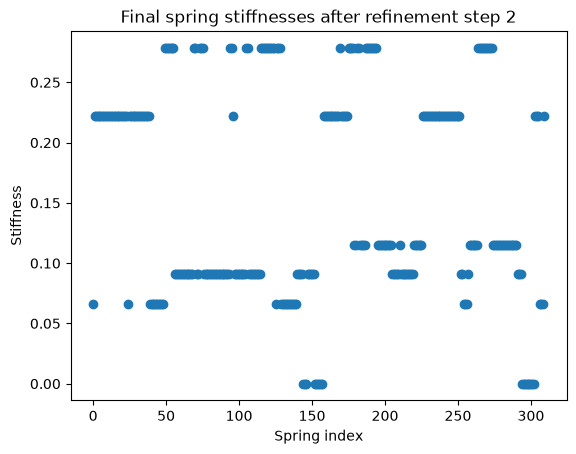

In [9]:
plt.scatter(np.arange(len(data['refineLog'][0][1][3].T[0])),data['refineLog'][0][1][3].T[0])
plt.title('Final spring stiffnesses after refinement step 2')
plt.ylabel('Stiffness')
plt.xlabel('Spring index')

In [10]:
#exactly twice as many as I have, since all springs are inter-cell! Probably the Gaussian parameter for each spring, 6 interfaces.
len(data['refineLog'][0][1][3].T[0])

310

Text(0.5, 0, 'Spring index')

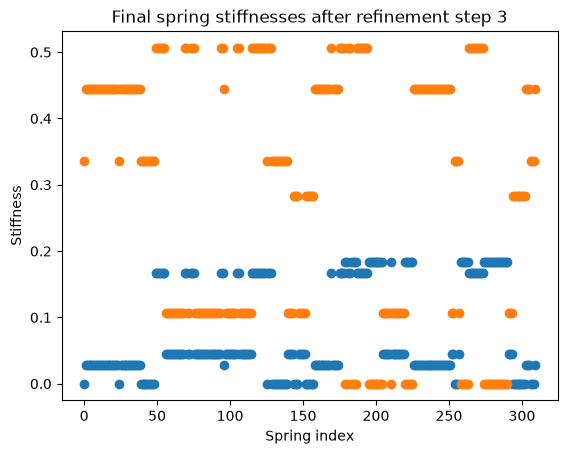

In [11]:
#probably the hybrid parameters for each spring, 6 interfaces.
plt.scatter(np.arange(len(data['refineLog'][0][2][3].T[0])),data['refineLog'][0][2][3].T[0])
plt.scatter(np.arange(len(data['refineLog'][0][2][3].T[1])),data['refineLog'][0][2][3].T[1])
plt.title('Final spring stiffnesses after refinement step 3')
plt.ylabel('Stiffness')
plt.xlabel('Spring index')

Text(0.5, 0, 'Spring index')

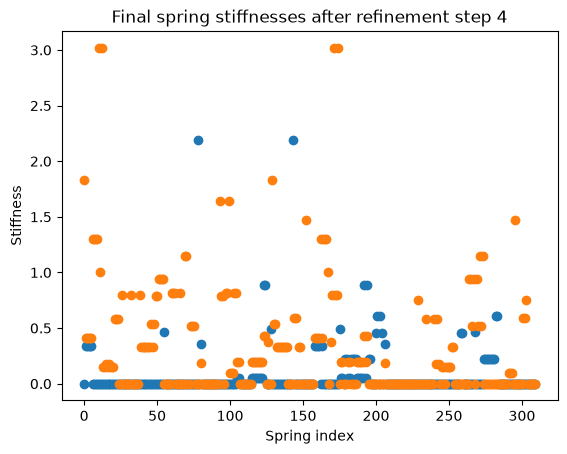

In [12]:
#probably the hybrid parameters for each spring, many different values at each interfaces.
plt.scatter(np.arange(len(data['refineLog'][0][3][3].T[0])),data['refineLog'][0][3][3].T[0])
plt.scatter(np.arange(len(data['refineLog'][0][3][3].T[1])),data['refineLog'][0][3][3].T[1])
plt.title('Final spring stiffnesses after refinement step 4')
plt.ylabel('Stiffness')
plt.xlabel('Spring index')

Text(0, 0.5, 'Stiffness')

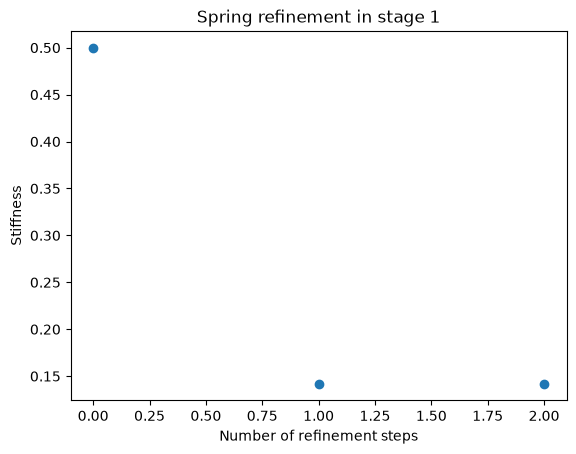

In [13]:
colors = plt.cm.tab20(np.linspace(0, 1, 20))
iters = []
for k in range(3):
    iters.append(data['refineLog'][0][0][1][k][0][1][0][0])
plt.scatter(np.arange(len(iters)),iters, color=colors[0])
plt.title('Spring refinement in stage 1')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

Text(0, 0.5, 'Stiffness')

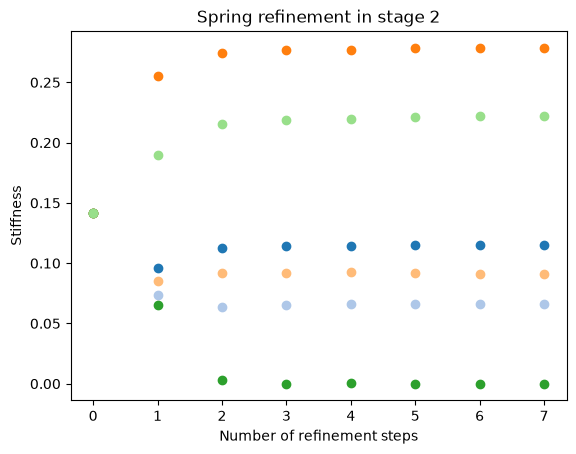

In [14]:
iters = []
for k in range(8):
    iters.append(data['refineLog'][0][1][1][k][0][1])
iters=np.array(iters)
for k in range(len(iters.T[0])):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(iters.T[0][k])),iters.T[0][k], color=color)
plt.title('Spring refinement in stage 2')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

Text(0, 0.5, 'Stiffness')

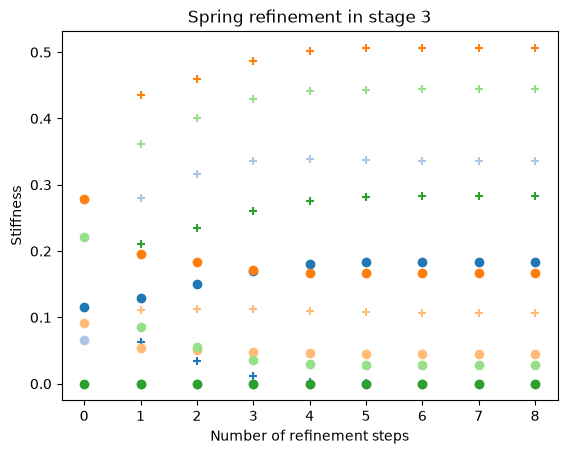

In [15]:
k1s = []
k2s = []
for k in range(9):
    k1s.append(data['refineLog'][0][2][1][k][0][1].T[0])
    k2s.append(data['refineLog'][0][2][1][k][0][1].T[1])
k1s=np.array(k1s)
k2s=np.array(k2s)
for k in range(len(k1s.T)):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(k1s.T[k])),k1s.T[k], color=color)
    plt.scatter(np.arange(len(k2s.T[k])),k2s.T[k], color=color,marker='+')
    
plt.title('Spring refinement in stage 3')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

Text(0, 0.5, 'Stiffness')

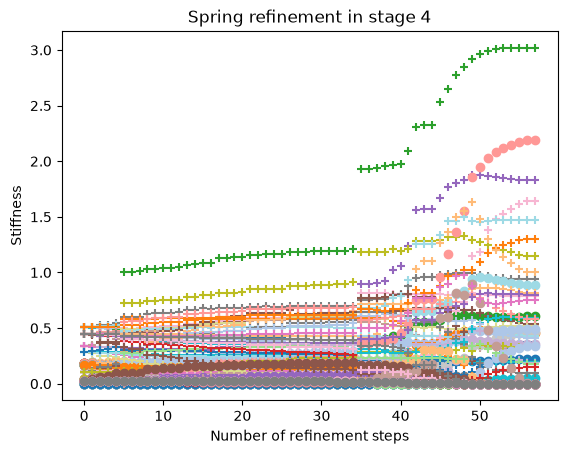

In [16]:
k1s = []
k2s = []
for k in range(58):
    k1s.append(data['refineLog'][0][3][1][k][0][1].T[0])
    k2s.append(data['refineLog'][0][3][1][k][0][1].T[1])
k1s=np.array(k1s)
k2s=np.array(k2s)
for k in range(len(k1s.T)):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(k1s.T[k])),k1s.T[k], color=color)
    plt.scatter(np.arange(len(k2s.T[k])),k2s.T[k], color=color,marker='+')
    
plt.title('Spring refinement in stage 4')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

Text(0, 0.5, 'Stiffness')

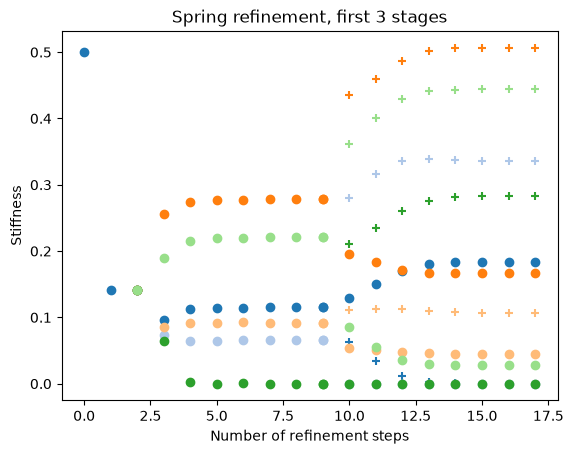

In [17]:
#Stage 1
iters = []
for k in range(3):
    iters.append(data['refineLog'][0][0][1][k][0][1][0][0])
plt.scatter(np.arange(len(iters)),iters, color=colors[0])

#Stage 2
iters = []
for k in range(8):
    iters.append(data['refineLog'][0][1][1][k][0][1])
iters=np.array(iters)
for k in range(len(iters.T[0])):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(iters.T[0][k]))+2,iters.T[0][k], color=color)
plt.title('Spring refinement in stage 2')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

#Stage 3
k1s = []
k2s = []
for k in range(9):
    k1s.append(data['refineLog'][0][2][1][k][0][1].T[0])
    k2s.append(data['refineLog'][0][2][1][k][0][1].T[1])
k1s=np.array(k1s)
k2s=np.array(k2s)
for k in range(len(k1s.T)):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(k1s.T[k]))+9,k1s.T[k], color=color)
    plt.scatter(np.arange(len(k2s.T[k]))+9,k2s.T[k], color=color,marker='+')

plt.title('Spring refinement, first 3 stages')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

Text(0, 0.5, 'Stiffness')

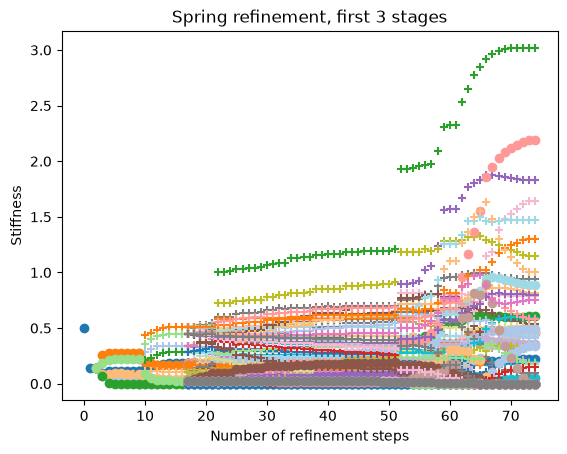

In [18]:
#Stage 1
iters = []
for k in range(3):
    iters.append(data['refineLog'][0][0][1][k][0][1][0][0])
plt.scatter(np.arange(len(iters)),iters, color=colors[0])

#Stage 2
iters = []
for k in range(8):
    iters.append(data['refineLog'][0][1][1][k][0][1])
iters=np.array(iters)
for k in range(len(iters.T[0])):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(iters.T[0][k]))+2,iters.T[0][k], color=color)
plt.title('Spring refinement in stage 2')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

#Stage 3
k1s = []
k2s = []
for k in range(9):
    k1s.append(data['refineLog'][0][2][1][k][0][1].T[0])
    k2s.append(data['refineLog'][0][2][1][k][0][1].T[1])
k1s=np.array(k1s)
k2s=np.array(k2s)
for k in range(len(k1s.T)):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(k1s.T[k]))+9,k1s.T[k], color=color)
    plt.scatter(np.arange(len(k2s.T[k]))+9,k2s.T[k], color=color,marker='+')

#Stage 4
k1s = []
k2s = []
for k in range(58):
    k1s.append(data['refineLog'][0][3][1][k][0][1].T[0])
    k2s.append(data['refineLog'][0][3][1][k][0][1].T[1])
k1s=np.array(k1s)
k2s=np.array(k2s)
for k in range(len(k1s.T)):
    color = colors[k % len(colors)]
    plt.scatter(np.arange(len(k1s.T[k]))+17,k1s.T[k], color=color)
    plt.scatter(np.arange(len(k2s.T[k]))+17,k2s.T[k], color=color,marker='+')

plt.title('Spring refinement, first 3 stages')
plt.xlabel('Number of refinement steps')
plt.ylabel('Stiffness')

In [19]:
#See if enm_edges.csv is plausibly correctly sorted.
df = pd.read_csv('enm_edges_grouped.csv')

Text(0.5, 0, 'Spring index')

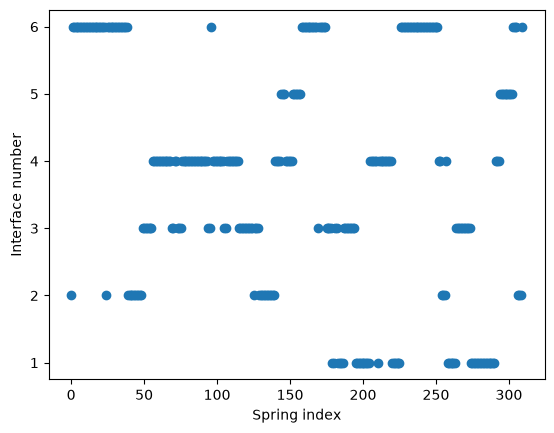

In [20]:
plt.scatter(np.arange(310),np.abs(np.array(df['interface'])))
plt.ylabel('Interface number')
plt.xlabel('Spring index')

Text(0.5, 0, 'Spring index')

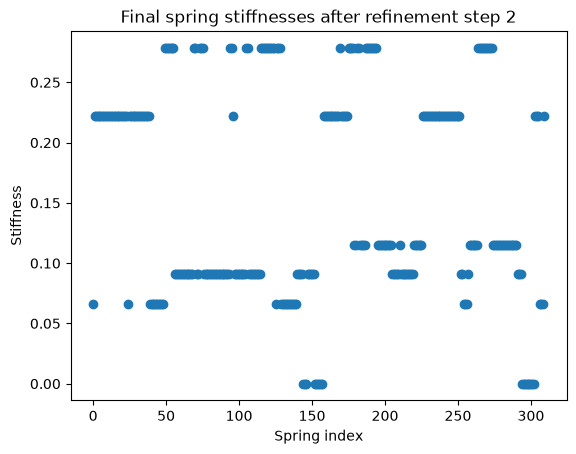

In [21]:
plt.scatter(np.arange(len(data['refineLog'][0][1][3].T[0])),data['refineLog'][0][1][3].T[0])
plt.title('Final spring stiffnesses after refinement step 2')
plt.ylabel('Stiffness')
plt.xlabel('Spring index')

In [22]:
#define factors = 1/spring constant for first instance of each interface.
factors = []
for interface_no in range(6):
    factors.append(data['refineLog'][0][1][3].T[0][np.where(np.abs(np.array(df['interface']))==interface_no+1)[0][0]]**-1)
#Check if all springs in the same interface are the same by multiplying them by their corresponding factors and seeing if they're nearly 1.
check = []
for spring in range(310):
    check.append((data['refineLog'][0][1][3].T[0][spring])*factors[np.abs(df['interface'][spring])-1])

In [23]:
#Excellent.
np.isclose(check, np.ones(len(check))).all()

np.True_

In [24]:
#Now I want a map from the parameters in each fitting step to my 155 symmetry classes.
#In refinement stage 1, all springs are Gaussian and the same.
#    The spring constant should be mapped to 155x[kL,kT] with kL=kT.
#In refinement stage 2, all springs are Gaussian and the same if they belong to the same interface. 
#    The 6 interface values should be mapped to 155x[kL,kT], with many values duplicated due to the interface.
#In refinement stage 3, the springs are allowed to become hybrid with [kL,kT] recorded.
#    The 12 values should be mapped to 155x[kL,kT] , with many values duplicated due to the interface.
#In refinement stage 4, each spring has its own [kL,kT] unless it belongs to the same inter-residue contact.

#Start with the easy bit: refinement stage 1.
spring_vals = []

for k in range(3):
    spring_vals.append(np.full((155,2),data['refineLog'][0][0][1][k][0][1][0][0]))

#Done. Now refinement step 2. Need a map from interfaces to all springs.
#Can be done by (1) using df[interface] to get many-to-one map from refinelog -> spring_index, then (r1,r2,r3) to get from spring_index to spring class.

In [25]:
df_symmetry = pd.read_csv('lysozyme_bonds.csv')

In [26]:
r1s = []
r2s = []
for i in range(155):
    r1s.append(np.array(eval(df_symmetry['r1'][i])))
    r2s.append(np.array(eval(df_symmetry['r2'][i])))

r1s = np.array(r1s)
r2s = np.array(r2s)

r1l = []
r2l = []
for i in range(310):
    r1l.append(np.array([df['r1_1'][i],df['r1_2'][i],df['r1_3'][i]]))
    r2l.append(np.array([df['r2_1'][i],df['r2_2'][i],df['r2_3'][i]]))

r1l = np.array(r1l)
r2l = np.array(r2l)

In [27]:
#map from lysozyme_bonds to enm_edges.
#The first atom location in each array is inside the unit cell.
#need to play with tolerance a bit.
mapping = []
for i in range(155):
    for j in range(310):
        if np.isclose(r2l[j]-r1l[j],r2s[i]-r1s[i], rtol=0, atol=1e-02).all():
            mapping.append((i,j))
        if np.isclose(-1.0*(r2l[j]-r1l[j]),r2s[i]-r1s[i], rtol=0, atol=1e-02).all():
            mapping.append((i,j))

In [28]:
len(mapping)

310

In [29]:
#Start with the easy bit: refinement stage 1.
spring_vals = []

for k in range(3):
    spring_vals.append(np.full((155,2),data['refineLog'][0][0][1][k][0][1][0][0]))

#refinement stage 2: Gaussian springs different at interfaces.
for k in range(8):
    springs = np.zeros((155,2))
    for interface in range(6):
        #each springs[w] is redundantly assigned twice, but this is fine.
        for index in np.where(np.abs(np.array(df['interface']))==interface+1)[0]:
            w = mapping[np.where(np.array(mapping)[:,1]==index)[0][0]][0]
            springs[w] = np.full(2, data['refineLog'][0][1][1][k][0][1][interface])
    spring_vals.append(springs)

#refinement stage 3: hybrid springs different at interfaces.
for k in range(9):
    springs = np.zeros((155,2))
    for interface in range(6):
        #each springs[w] is redundantly assigned twice, but this is fine.
        for index in np.where(np.abs(np.array(df['interface']))==interface+1)[0]:
            w = mapping[np.where(np.array(mapping)[:,1]==index)[0][0]][0]
            springs[w] = np.array([data['refineLog'][0][2][1][k][0][1].T[0][interface],data['refineLog'][0][2][1][k][0][1].T[1][interface]])
    spring_vals.append(springs)

#refinement stage 4: grouped into 55 residue-level classes. Based on residue_group_index.
for k in range(58):
    springs = np.zeros((155,2))
    #For every residue-level spring class:
    for spring_class in range(55):
        #Get a list of indices in [0,309] that correspond to bonds that are in that class.
        for index in np.where(np.abs(np.array(df['residue_group_index']))==spring_class+1)[0]:
            #For each of those indices, identify the w and assign springs[w]. This may assign spring[w] many times.
            w = mapping[np.where(np.array(mapping)[:,1]==index)[0][0]][0]
            springs[w] = np.array([data['refineLog'][0][3][1][k][0][1].T[0][spring_class],data['refineLog'][0][3][1][k][0][1].T[1][spring_class]])
    spring_vals.append(springs)

In [30]:
np.shape(np.array(spring_vals))

(78, 155, 2)

In [31]:
np.save('krefinement.npy',np.array(spring_vals))